In [158]:
# Task 1: Iris Flower Classification

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Iris dataset from scikit-learn
from sklearn.datasets import load_iris

# Load the dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target/species column
df["species"] = iris.target
df["species_name"] = df["species"].map(
    {0: "Setosa", 1: "Versicolor", 2: "Virginica"}
)

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [159]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

Dataset Shape: (150, 6)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name             str
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [160]:
# Species distribution

species_counts = df["species_name"].value_counts()

print("Species Distribution:")
print(species_counts)

print("\nSpecies Percentages:")
print((species_counts / len(df) * 100).round(2))

Species Distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

Species Percentages:
species_name
Setosa        33.33
Versicolor    33.33
Virginica     33.33
Name: count, dtype: float64


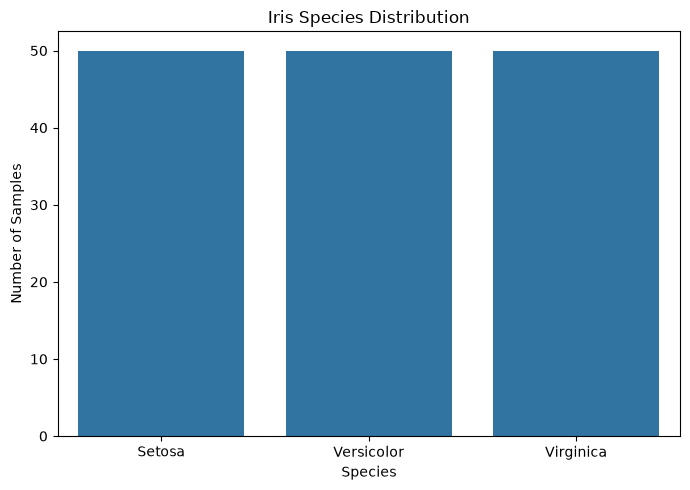

In [161]:
# Visualize species distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="species_name"
)

plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

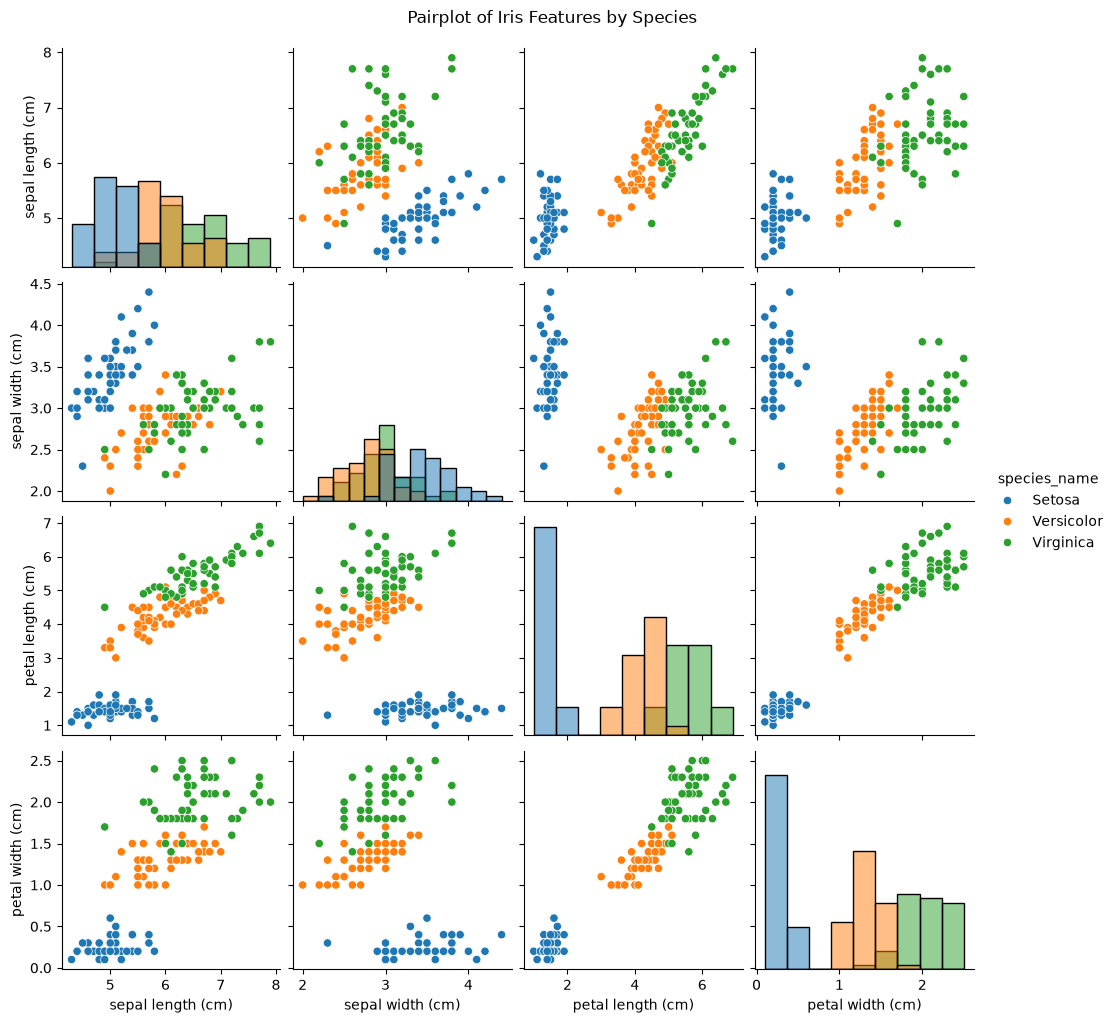

In [162]:
# Pairplot to visualize relationships between Iris features

sns.pairplot(
    df,
    vars=iris.feature_names,
    hue="species_name",
    diag_kind="hist"
)

plt.suptitle(
    "Pairplot of Iris Features by Species",
    y=1.02
)

plt.show()

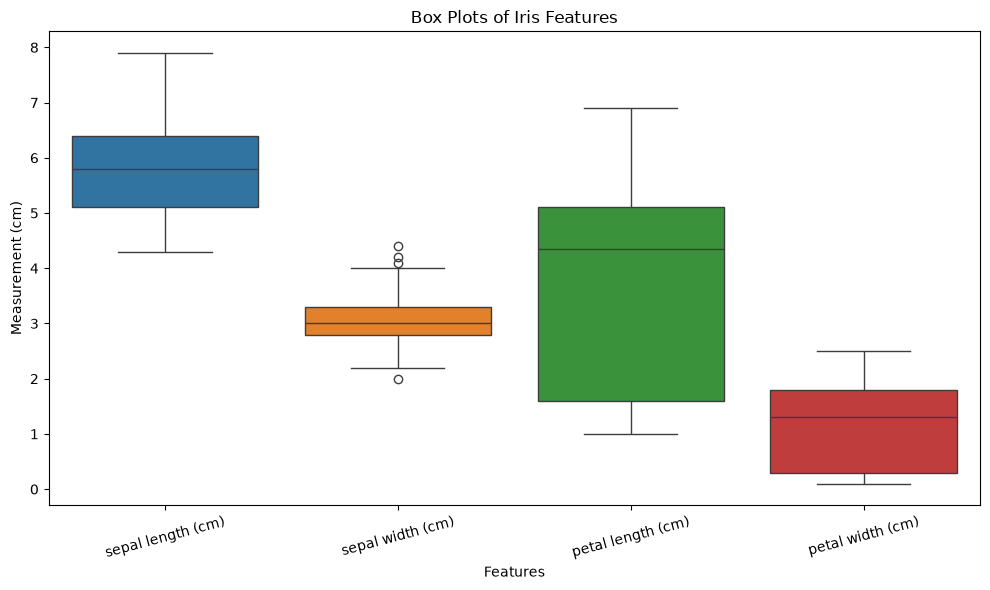

In [163]:
# Box plots for all Iris features

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[iris.feature_names]
)

plt.title("Box Plots of Iris Features")
plt.xlabel("Features")
plt.ylabel("Measurement (cm)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Feature Selection Discussion

The Iris dataset contains four features: sepal length, sepal width, petal length, and petal width.

From the pairplot and box plots, **petal length and petal width appear to be the most discriminative features** for distinguishing the three Iris species. Setosa is clearly separated from the other species using these features, while petal measurements also provide good separation between Versicolor and Virginica.

Sepal length and sepal width are useful features, but they show more overlap between the species.

Therefore, **petal length and petal width are the most important features for identifying Iris species**, although all four features can be retained when training the classification models.

In [164]:
# Prepare features and target

X = df[iris.feature_names]
y = df["species"]

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (120, 4)
Testing set size: (30, 4)


In [165]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression predictions:")
print(y_pred_logistic)

Logistic Regression predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [166]:
# Evaluate Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, average="weighted")
recall_logistic = recall_score(y_test, y_pred_logistic, average="weighted")
f1_logistic = f1_score(y_test, y_pred_logistic, average="weighted")

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1-Score : {f1_logistic:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=iris.target_names
))

Logistic Regression Results
---------------------------
Accuracy : 0.9667
Precision: 0.9697
Recall   : 0.9667
F1-Score : 0.9666

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



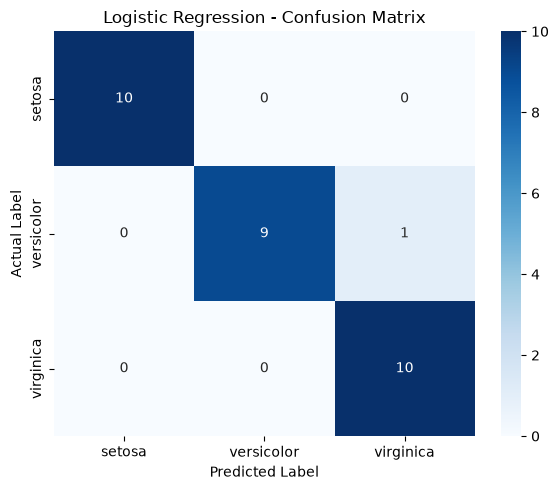

In [167]:
# Confusion Matrix - Logistic Regression

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [168]:
# Train Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions:")
print(y_pred_rf)

Random Forest predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]


In [169]:
# Evaluate Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=iris.target_names
))

Random Forest Results
---------------------
Accuracy : 0.9000
Precision: 0.9024
Recall   : 0.9000
F1-Score : 0.8997

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



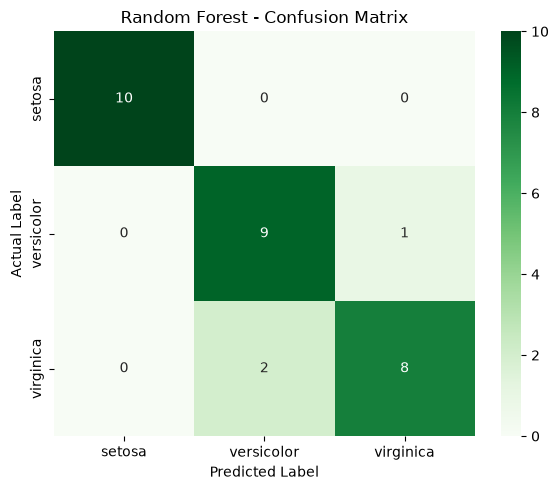

In [170]:
# Confusion Matrix - Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [171]:
# Compare model performance

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_logistic, accuracy_rf],
    "Precision": [precision_logistic, precision_rf],
    "Recall": [recall_logistic, recall_rf],
    "F1-Score": [f1_logistic, f1_rf]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.966667,0.969697,0.966667,0.966583
1,Random Forest,0.900000,0.902357,0.900000,0.899749


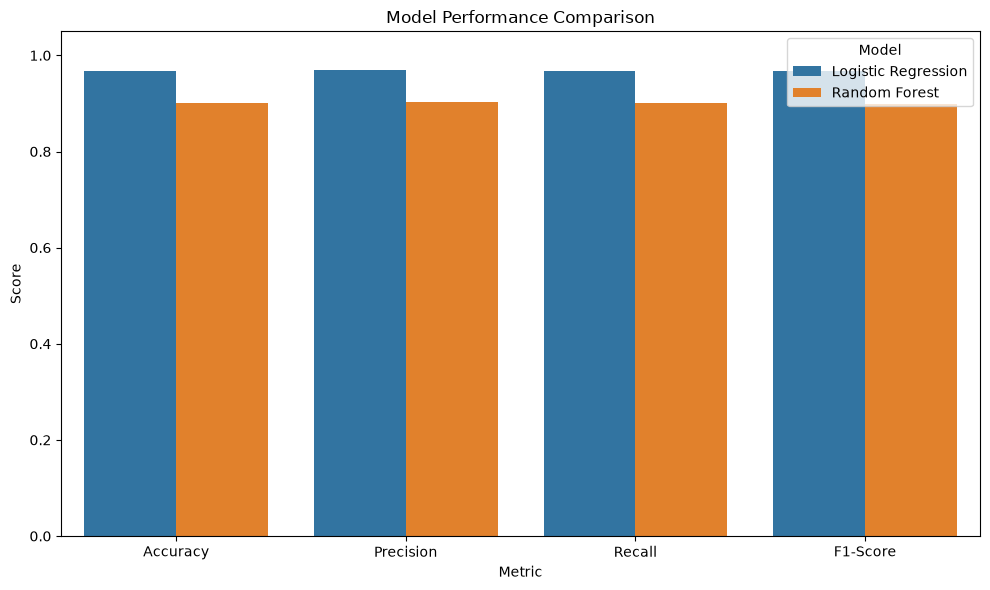

In [172]:
# Visualize model comparison

results_melted = results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Best-Performing Model

Two classification models were evaluated: Logistic Regression and Random Forest.

Logistic Regression achieved the best overall performance:

- Accuracy: **96.67%**
- Precision: **96.97%**
- Recall: **96.67%**
- F1-Score: **96.66%**

Random Forest achieved:

- Accuracy: **90.00%**
- Precision: **90.24%**
- Recall: **90.00%**
- F1-Score: **89.97%**

Therefore, **Logistic Regression was selected as the best-performing model** because it achieved the highest accuracy, precision, recall, and F1-score among the two models tested.

In [173]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": random_forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


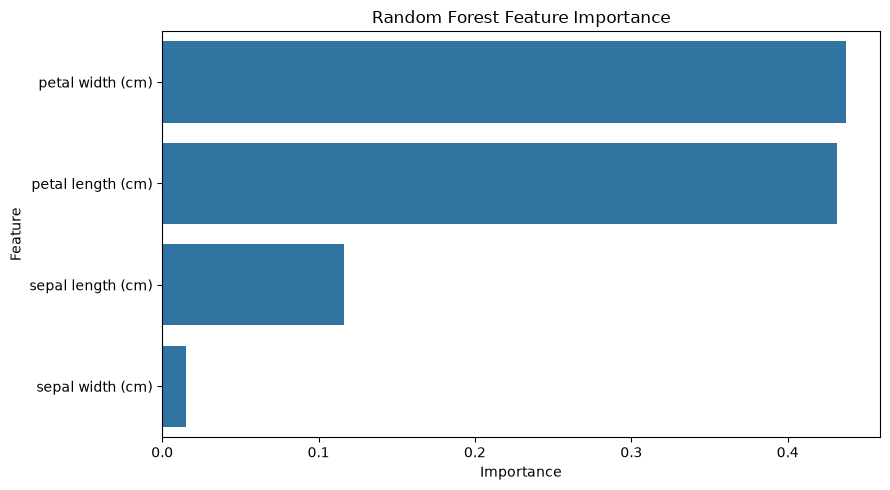

In [174]:
# Feature Importance Visualization

plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Conclusion

This project successfully developed machine learning models to classify Iris flowers into three species: Setosa, Versicolor, and Virginica.

Exploratory data analysis showed that **petal length and petal width are the most discriminative features**, providing strong separation between the three species.

Two classification algorithms were trained and evaluated: Logistic Regression and Random Forest.

Logistic Regression achieved the best performance with an accuracy of **96.67%**, precision of **96.97%**, recall of **96.67%**, and F1-score of **96.66%**. Random Forest achieved an accuracy of **90.00%**.

Therefore, **Logistic Regression was selected as the final model** for Iris species classification.

The project demonstrates a complete machine learning classification workflow, including data exploration, visualization, feature analysis, model training, evaluation, comparison, and interpretation.

## Feature Importance Discussion

The Random Forest feature importance analysis shows that **petal width and petal length are the most important features** for Iris species classification.

- Petal width: **0.437185**
- Petal length: **0.431466**
- Sepal length: **0.116349**
- Sepal width: **0.015000**

Petal width and petal length together contribute approximately **86.87%** of the total feature importance. This confirms the observations from the pairplot and box plots that petal measurements provide the strongest separation between the Iris species.

Sepal width has the lowest feature importance, while sepal length provides a smaller contribution compared with the petal measurements.